# 1. Data Collection & Augmentation

Load images from directories and visualize on-the-fly augmentation.

**Goal:**
- ~400 images exist per category (Anchor, Positive)
- On-the-fly augmentation generates variations during training
- Data is not stored on disk (optimized for storage space)

## 1.1 Import & Setup

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

# Project
sys.path.insert(0, str(Path.cwd().parent))
import config
from src import data
from src import utils

print("✓ Imports successful")
print(f"Project Root: {config.PROJECT_ROOT}")

✓ Imports successful
Project Root: C:\Users\angel\Documents\AI Master3.Semester\Doyourecognizeme


## 1.2 Load and Verify Images

In [3]:
# ==========================================
# DATA DIRECTORY CHECK & VALIDATION
# ==========================================
print("\n" + "="*80)
print("DATA DIRECTORY CHECK")
print("="*80)

# Dictionary to store file counts for the validation check
counts = {}

for dir_name, dir_path in [
    ('Anchor', config.ANCHOR_PATH),
    ('Positive', config.POSITIVE_PATH),
    ('Negative', config.NEGATIVE_PATH),
]:
    if dir_path.exists():
        files = list(dir_path.glob('*.*'))
        counts[dir_name] = len(files)
        print(f"\n✓ {dir_name}: {len(files)} images")
        if files:
            print(f"  Examples: {[f.name for f in files[:3]]}")
    else:
        counts[dir_name] = 0
        print(f"\n✗ {dir_name}: Directory not found!")

print("\n" + "="*80)
print("DATASET VALIDATION")
print("="*80)

validation_passed = True
errors = []

# 1. Check if Anchor or Positive is completely empty
if counts.get('Anchor', 0) == 0 or counts.get('Positive', 0) == 0:
    validation_passed = False
    errors.append(
        "  [PROBLEM] Anchor or Positive folder is empty!\n"
        "            --> Please run 'webcam_data_collection.py' to capture the required images."
    )

# 2. Check if total images in Anchor + Positive is less than 400
elif (counts.get('Anchor', 0) + counts.get('Positive', 0)) < 400:
    validation_passed = False
    errors.append(
        f"  [WARNING] Low dataset size! You only have {counts.get('Anchor', 0) + counts.get('Positive', 0)} images in total (Anchor + Positive).\n"
        f"            --> Please collect at least 300 images across these two folders for stable training.\n"
        f"                You can use the 'webcam_data_collection.py' script to capture images."
    )

# 3. Check if Negative folder is empty
if counts.get('Negative', 0) == 0:
    validation_passed = False
    errors.append(
        "  [PROBLEM] Negative folder is empty!\n"
        "            --> Please fill the 'negative' dataset folder with face images."
    )

# Output validation results
if validation_passed:
    print("  ✓ Dataset validation passed! Ready for training.")
    print("="*80)
else:
    for error in errors:
        print(error)
    print("\n  [STATUS] Training cannot start. Please resolve the issues above.")
    print("="*80)
    import sys
    sys.exit(1)


DATA DIRECTORY CHECK

✓ Anchor: 523 images
  Examples: ['2571fed5-793f-11f1-ab75-ac198e6292dc.jpg', '25c2dde2-793f-11f1-aec9-ac198e6292dc.jpg', '25db4aad-793f-11f1-99cb-ac198e6292dc.jpg']

✓ Positive: 523 images
  Examples: ['1fabc075-793f-11f1-8da1-ac198e6292dc.jpg', '1fb25555-793f-11f1-8036-ac198e6292dc.jpg', '1fb99ac0-793f-11f1-bf5b-ac198e6292dc.jpg']

✓ Negative: 13233 images
  Examples: ['Aaron_Eckhart_0001.jpg', 'Aaron_Guiel_0001.jpg', 'Aaron_Patterson_0001.jpg']

DATASET VALIDATION
  ✓ Dataset validation passed! Ready for training.


## 1.3 Load Images

In [4]:
# Load image paths
print("\nLoading image paths...")

try:
    anchor_paths = data.load_image_paths(str(config.ANCHOR_PATH))
    print(f"✓ {len(anchor_paths)} Anchor images")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    anchor_paths = []

try:
    positive_paths = data.load_image_paths(str(config.POSITIVE_PATH))
    print(f"✓ {len(positive_paths)} Positive images")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    positive_paths = []

try:
    negative_paths = data.load_image_paths(str(config.NEGATIVE_PATH))
    print(f"✓ {len(negative_paths)} Negative images")
except FileNotFoundError as e:
    print(f"✗ Error: {e}")
    negative_paths = []

print(f"\nTotal: {len(anchor_paths) + len(positive_paths) + len(negative_paths)} images")


Loading image paths...
✓ 400 Anchor images
✓ 400 Positive images
✓ 400 Negative images

Total: 1200 images


## 1.4 Dataset Statistics

In [5]:
# Show statistics
stats = data.get_dataset_stats(
    str(config.ANCHOR_PATH),
    str(config.POSITIVE_PATH),
    str(config.NEGATIVE_PATH)
)

print("\n" + "="*80)
print("DATASET STATISTICS")
print("="*80)

print(f"\nAvailable Images:")
print(f"  Anchor: {stats['anchor']}")
print(f"  Positive: {stats['positive']}")
print(f"  Negative: {stats['negative']}")
print(f"  Minimum: {stats['min']}")

print(f"\nTraining Pairs:")
print(f"  Total Pairs: {stats['total_pairs']}")
print(f"  Positive Pairs: {stats['min']}")
print(f"  Negative Pairs: {stats['min']}")

print(f"\nAugmentation:")
print(f"  On-The-Fly: Yes")
print(f"  Strategy: Each image is augmented differently in every epoch")
print(f"  Transformations: Brightness, Contrast, Saturation, Flip")

print("\n" + "="*80)


DATASET STATISTICS

Available Images:
  Anchor: 400
  Positive: 400
  Negative: 2000
  Minimum: 400

Training Pairs:
  Total Pairs: 2400
  Positive Pairs: 400
  Negative Pairs: 400

Augmentation:
  On-The-Fly: Yes
  Strategy: Each image is augmented differently in every epoch
  Transformations: Brightness, Contrast, Saturation, Flip



## 1.5 Visualize Sample Images

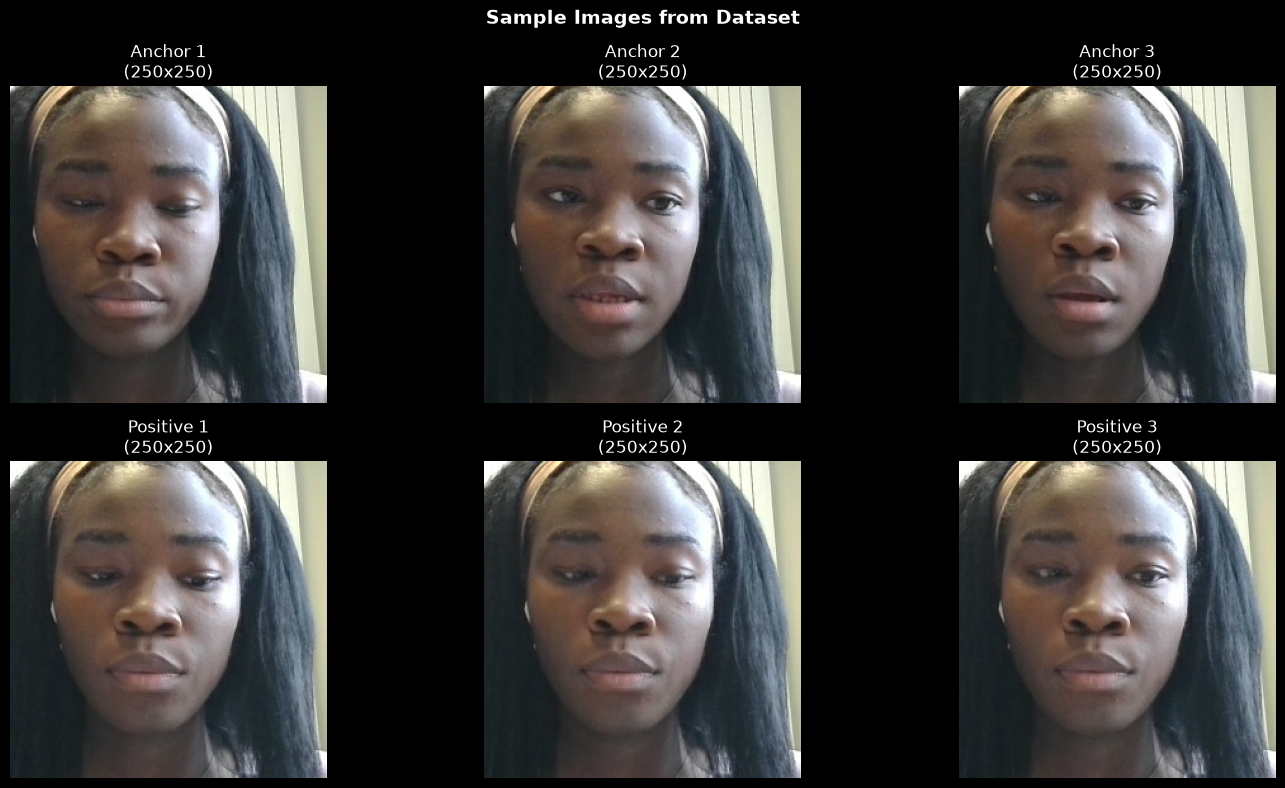

✓ Sample images displayed


In [6]:
# Load and visualize sample images
if anchor_paths and positive_paths:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')

    # Anchor
    for i in range(3):
        img = data.load_image(anchor_paths[i]).numpy().astype(np.uint8)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Anchor {i+1}\n({img.shape[0]}x{img.shape[1]})')
        axes[0, i].axis('off')

    # Positive
    for i in range(3):
        img = data.load_image(positive_paths[i]).numpy().astype(np.uint8)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'Positive {i+1}\n({img.shape[0]}x{img.shape[1]})')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
    print("✓ Sample images displayed")
else:
    print(" Not enough images to visualize")

## 1.6 Visualize On-The-Fly Augmentation

Generating 10 augmented versions of the same image...



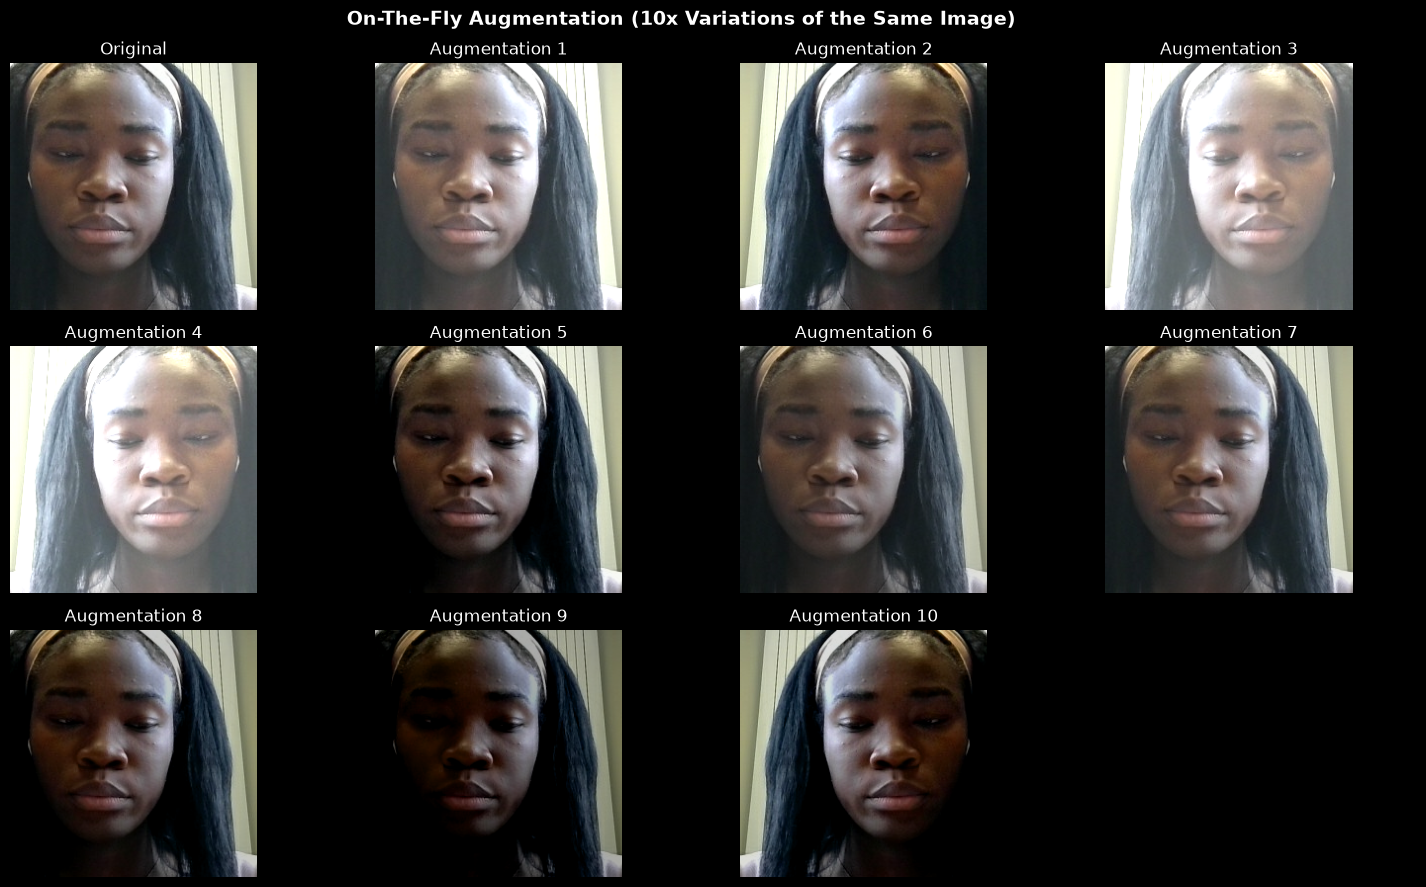

✓ Augmentation visualized


In [7]:
# Augment single image and show variations
if anchor_paths:
    # Load image
    original_img = data.load_image(anchor_paths[0]).numpy()
    original_img_normalized = original_img / 255.0

    print("Generating 10 augmented versions of the same image...\n")

    # Augment multiple times
    augmented_imgs = []
    for i in range(10):
        aug_img = data.augment_image(tf.convert_to_tensor(original_img_normalized))
        augmented_imgs.append(aug_img.numpy())

    # Visualize
    fig = utils.visualize_augmentations(
        original_img_normalized,
        augmented_imgs,
        title="On-The-Fly Augmentation (10x Variations of the Same Image)"
    )
    plt.show()

    print("✓ Augmentation visualized")
else:
    print(" No images found")

## 1.7 Create Triplet Dataset Preview

Creating Triplet Dataset...


📊 Dataset Balancing:
  Anchor/Positive Pairs: 10
  Negative Samples:     10
  Total Pairs per Epoch: 20
✓ Dataset created

Dataset Element Spec:
  (TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.float32, name=None))

Example Triplet:
  Anchor: (100, 100, 3) | Range: [0.0675, 1.0000]
  Verification: (100, 100, 3) | Range: [0.0000, 0.7937]
  Label: 1.0 (0=different, 1=same)


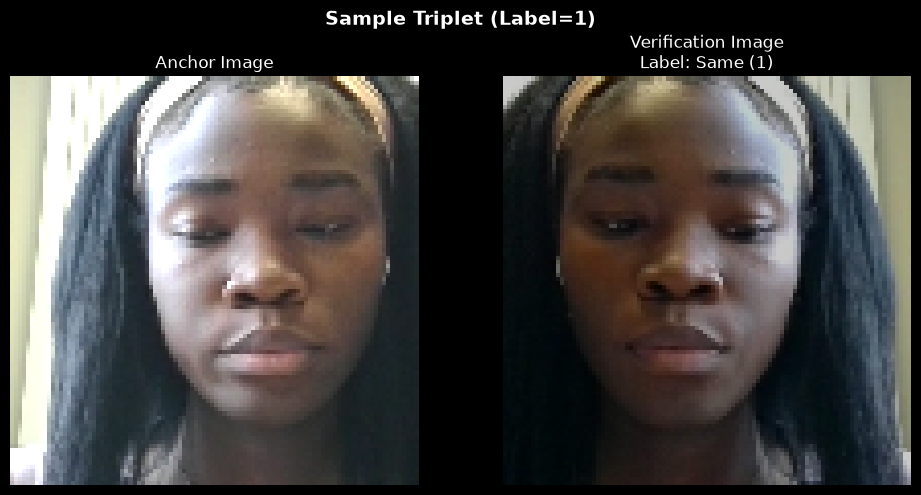

In [9]:
if anchor_paths and positive_paths and negative_paths:
    print("Creating Triplet Dataset...\n")

    # Create Dataset with Augmentation
    dataset = data.create_triplet_dataset(
        anchor_paths[:10],  # Only 10 for preview
        positive_paths[:10],
        negative_paths[:10],
        apply_augmentation=True
    )

    print(f"✓ Dataset created")

    # Show Element Spec
    print(f"\nDataset Element Spec:")
    print(f"  {dataset.element_spec}")

    # Show first sample
    for anchor, verification, label in dataset.take(1):
        print(f"\nExample Triplet:")
        print(f"  Anchor: {anchor.shape} | Range: [{anchor.numpy().min():.4f}, {anchor.numpy().max():.4f}]")
        print(f"  Verification: {verification.shape} | Range: [{verification.numpy().min():.4f}, {verification.numpy().max():.4f}]")
        print(f"  Label: {label.numpy()} (0=different, 1=same)")

        # Visualize
        fig = utils.visualize_sample_pair(
            anchor.numpy(),
            verification.numpy(),
            label.numpy(),
            title=f"Sample Triplet (Label={int(label.numpy())})"
        )
        plt.show()
else:
    print(" Not all directories contain images")

## 1.8 Summary and Next Steps

In [11]:
print("\n" + "="*80)
print("DATA COLLECTION SUMMARY")
print("="*80)

print(f"\n✓ Images loaded: {len(anchor_paths) + len(positive_paths) + len(negative_paths)}")
print(f"✓ Augmentation configured (Brightness, Contrast, Saturation, Flip)")
print(f"✓ On-The-Fly Pipeline functional")
print(f"✓ Dataset Triplet Format verified")

print(f"\nNext Step:")
print(f"1. Notebook 02_preprocessing.ipynb: Train/Test Split and Batching")

print("\n" + "="*80)
print("✓ Notebook 01 completed!")
print("="*80)


DATA COLLECTION SUMMARY

✓ Images loaded: 1200
✓ Augmentation configured (Brightness, Contrast, Saturation, Flip)
✓ On-The-Fly Pipeline functional
✓ Dataset Triplet Format verified

Next Step:
1. Notebook 02_preprocessing.ipynb: Train/Test Split and Batching

✓ Notebook 01 completed!
